In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


I0000 00:00:1780060821.982795  194223 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780060822.003907  194223 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Generating Data...


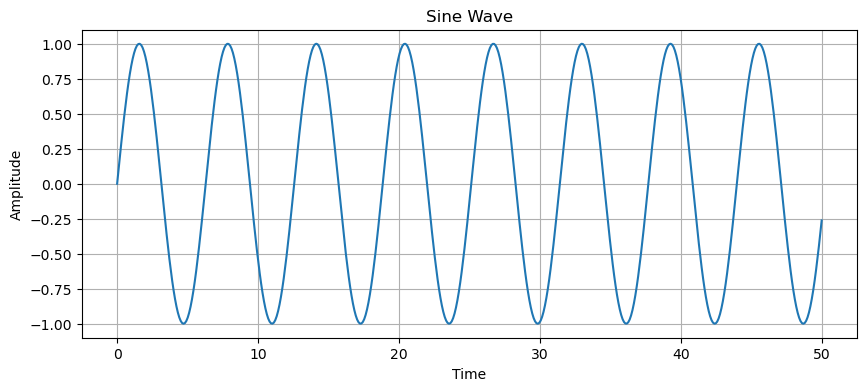

In [2]:
# --- 1. Generate Sequential Data (Sine Wave) ---
print("Generating Data...")
# Create a sine wave with 500 data points
x_axis = np.linspace(0, 50, 500)
sine_wave = np.sin(x_axis)

# plot the sine wave
plt.figure(figsize=(10, 4))
plt.plot(x_axis, sine_wave)
plt.title("Sine Wave")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

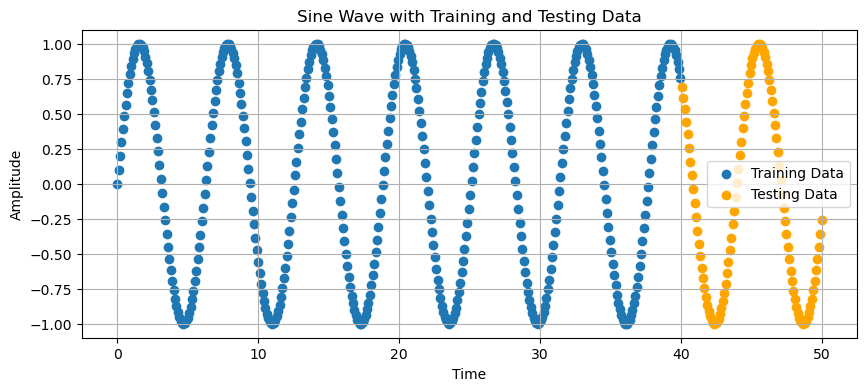

In [8]:
# --- 2. Prepare Data for the RNN ---
# RNNs need "windows" of time. We will give it 10 steps to predict the 11th step.
look_back = 10 
X_data, Y_data = [], []

for i in range(len(sine_wave) - look_back):
    X_data.append(sine_wave[i : i + look_back])
    Y_data.append(sine_wave[i + look_back])

# Convert to NumPy arrays and reshape for Keras RNNs
# Keras expects shape: (Number of Samples, Time Steps, Features)
X_data = np.array(X_data).reshape(-1, look_back, 1)
Y_data = np.array(Y_data)

# Split into Training and Testing sets (We will predict the last 100 points)
split_index = 390
X_train, Y_train = X_data[:split_index], Y_data[:split_index]
X_test, Y_test = X_data[split_index:], Y_data[split_index:]
test_x_axis = x_axis[split_index + look_back:] 

# plot the training and testing data
plt.figure(figsize=(10, 4))
plt.scatter(x_axis[:split_index + look_back], \
            sine_wave[:split_index + look_back], label="Training Data")
plt.scatter(test_x_axis, Y_test, label="Testing Data", color="orange")
plt.title("Sine Wave with Training and Testing Data")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()  

In [4]:
# --- 3. Build the RNN Architecture (Keras 3 Compliant) ---
print("Building RNN Model...")
model = models.Sequential([
    layers.Input(shape=(look_back, 1)),
    # SimpleRNN is the most basic recurrent layer. It loops over the 10 time steps.
    layers.SimpleRNN(32, activation='tanh'), 
    layers.Dense(1) # Output a single number (the predicted next point)
])

# Since this is a standard prediction task, we use Mean Squared Error (MSE)
model.compile(optimizer='adam', loss='mse')

# --- 4. Train the Model ---
print("Training RNN...")
# verbose=1 gives you a nice progress bar
model.fit(X_train, Y_train, epochs=20, batch_size=16, verbose=1)

# --- 5. Predict and Visualize ---
print("Testing Model on Future Data...")
# Ask the model to predict the test set
predictions = model.predict(X_test, verbose=0)

Building RNN Model...
Training RNN...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0349   
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046 
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0018 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.9332e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.6432e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6012e-04 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4738e-04 
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1359e-04 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.1695e-05 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.8863e-05 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5297e-05 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.6655e-05 
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.9986e-05 
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5

In [12]:
test_rmse = np.sqrt(np.mean((predictions.flatten() - Y_test) ** 2))
test_r2 = 1 - np.sum((Y_test - predictions.flatten()) ** 2) / np.sum((Y_test - np.mean(Y_test)) ** 2)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}")
train_rmse = np.sqrt(np.mean((model.predict(X_train, verbose=0).flatten() - Y_train) ** 2))
train_r2 = 1 - np.sum((Y_train - model.predict(X_train, verbose=0).flatten()) ** 2) / np.sum((Y_train - np.mean(Y_train)) ** 2)
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train R²: {train_r2:.4f}")


Test RMSE: 0.0067
Test R²: 0.9999
Train RMSE: 0.0069
Train R²: 0.9999


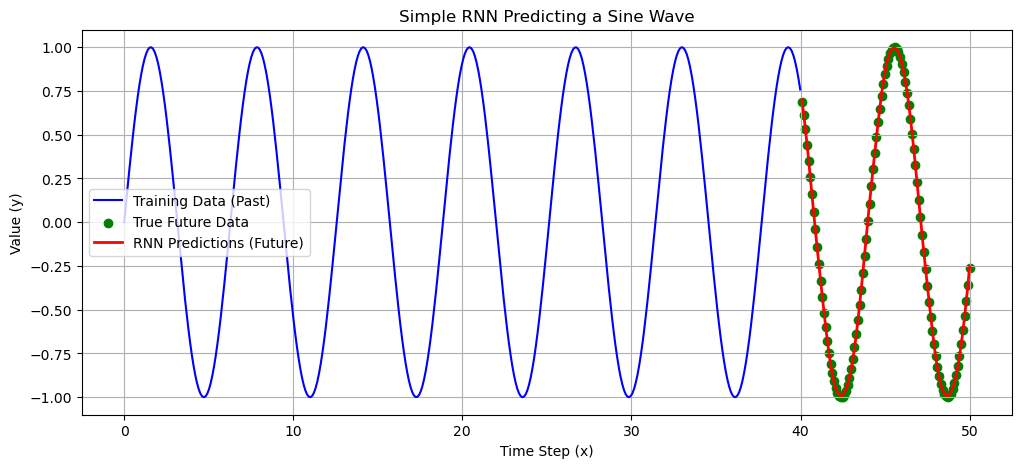

In [7]:
# Plot the results
plt.figure(figsize=(12, 5))

# Plot the training data the model was allowed to see
plt.plot(x_axis[:split_index + look_back], sine_wave[:split_index + look_back], 
         color='blue', label='Training Data (Past)')

# Plot the true future data
plt.scatter(test_x_axis, Y_test, color='green', marker='o', 
         label='True Future Data')

# Plot what the RNN predicted the future would look like
plt.plot(test_x_axis, predictions, color='red', linewidth=2, 
         label='RNN Predictions (Future)')

plt.title("Simple RNN Predicting a Sine Wave")
plt.xlabel("Time Step (x)")
plt.ylabel("Value (y)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# use instead a standarrd NN
# --- 3. Build the Standard NN Architecture ---
print("Building Standard NN Model...")
model = models.Sequential([
    layers.Input(shape=(look_back,)), # Accepts 10 flat numbers
    layers.Dense(32, activation='relu'), 
    layers.Dense(16, activation='relu'), 
    layers.Dense(1) # Predict the 11th number
])

model.compile(optimizer='adam', loss='mse')

# --- 4. Train the Model ---
print("Training Standard NN...")
model.fit(X_train, Y_train, epochs=20, batch_size=16, verbose=1)


Building Standard NN Model...
Training Standard NN...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3243  
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.0950
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0329 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0082 
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.0014
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - loss: 4.4180e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - loss: 2.6596e-04
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 1.7197e-04
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1815e-04 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - loss: 8.2347e-05
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.2020e-05 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.8670e-05 
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 4.0322e-05
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

In [18]:
test_rmse = np.sqrt(np.mean((model.predict(X_test, verbose=0).flatten() - Y_test) ** 2))
test_r2 = 1 - np.sum((Y_test - model.predict(X_test, verbose=0).flatten()) ** 2) / np.sum((Y_test - np.mean(Y_test)) ** 2)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}")
train_rmse = np.sqrt(np.mean((model.predict(X_train, verbose=0).flatten() - Y_train) ** 2))
train_r2 = 1 - np.sum((Y_train - model.predict(X_train, verbose=0).flatten()) ** 2) / np.sum((Y_train - np.mean(Y_train     )) ** 2)
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train R²: {train_r2:.4f}")

Test RMSE: 0.0042
Test R²: 1.0000
Train RMSE: 0.0042
Train R²: 1.0000


Testing Model on Future Data...


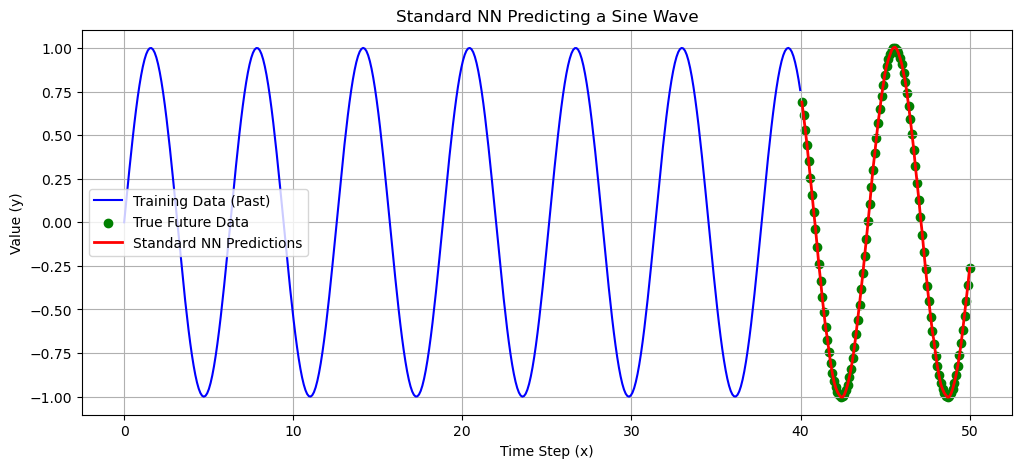

In [19]:
# --- 5. Predict and Visualize ---
print("Testing Model on Future Data...")
predictions = model.predict(X_test, verbose=0)

# Plot the results
plt.figure(figsize=(12, 5))

plt.plot(x_axis[:split_index + look_back], sine_wave[:split_index + look_back], 
         color='blue', label='Training Data (Past)')

plt.scatter(test_x_axis, Y_test, color='green', marker='o', 
         label='True Future Data')

plt.plot(test_x_axis, predictions, color='red', linewidth=2, 
         label='Standard NN Predictions')

plt.title("Standard NN Predicting a Sine Wave")
plt.xlabel("Time Step (x)")
plt.ylabel("Value (y)")
plt.legend()
plt.grid(True)
plt.show()